In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sidetable # pour les valeurs manquante

from sklearn.neighbors import KNeighborsRegressor, kneighbors_graph
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression #permet de creer le modele de regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,confusion_matrix,recall_score, f1_score



# Standardisation des données
from sklearn.preprocessing import StandardScaler

## 1. Chargez les données et les stocker dans une variable df.

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

# 2- Listons les différents modèles existants pour résoudre le problème ? 

## les differents model:
- Regression linaire Multiple
- knn de type regressif
- random forest de type regressif
- arbre de decision de type regressif
- svm par regressif
- 
Ces modèles permettent de prédire la variable cible Outcome à partir des caractéristiques des patients.

# 3- Implémentation de la phase de la préparation des données (vérification des valeurs manquantes, aberrantes, doublons)

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


- count: est le nombree total des colonnes.
- mean:est la moyenne de chaque variable
- std: est l'ecart-type 
- min:est le minimum de chaque variable 
- 25%: est la médiane 
- 50%:est la médiane 
- 75%: est le 3eme cartlie 
- max:la valeur la pllus grande

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
!pip install missingno

Defaulting to user installation because normal site-packages is not writeable


In [8]:
# voir les valeurs null
df.isnull().sum().sum()

np.int64(0)

## On constate que le jeu de données n'a aucune valeurs null.

In [9]:
## voir les valeurs manquante
df.stb.missing()

,missing,total,percent
Pregnancies,0,768,0.0
Glucose,0,768,0.0
BloodPressure,0,768,0.0
SkinThickness,0,768,0.0
Insulin,0,768,0.0
BMI,0,768,0.0
DiabetesPedigreeFunction,0,768,0.0
Age,0,768,0.0
Outcome,0,768,0.0


In [10]:
import missingno as msno # pour visualiser les valeurs manquantes

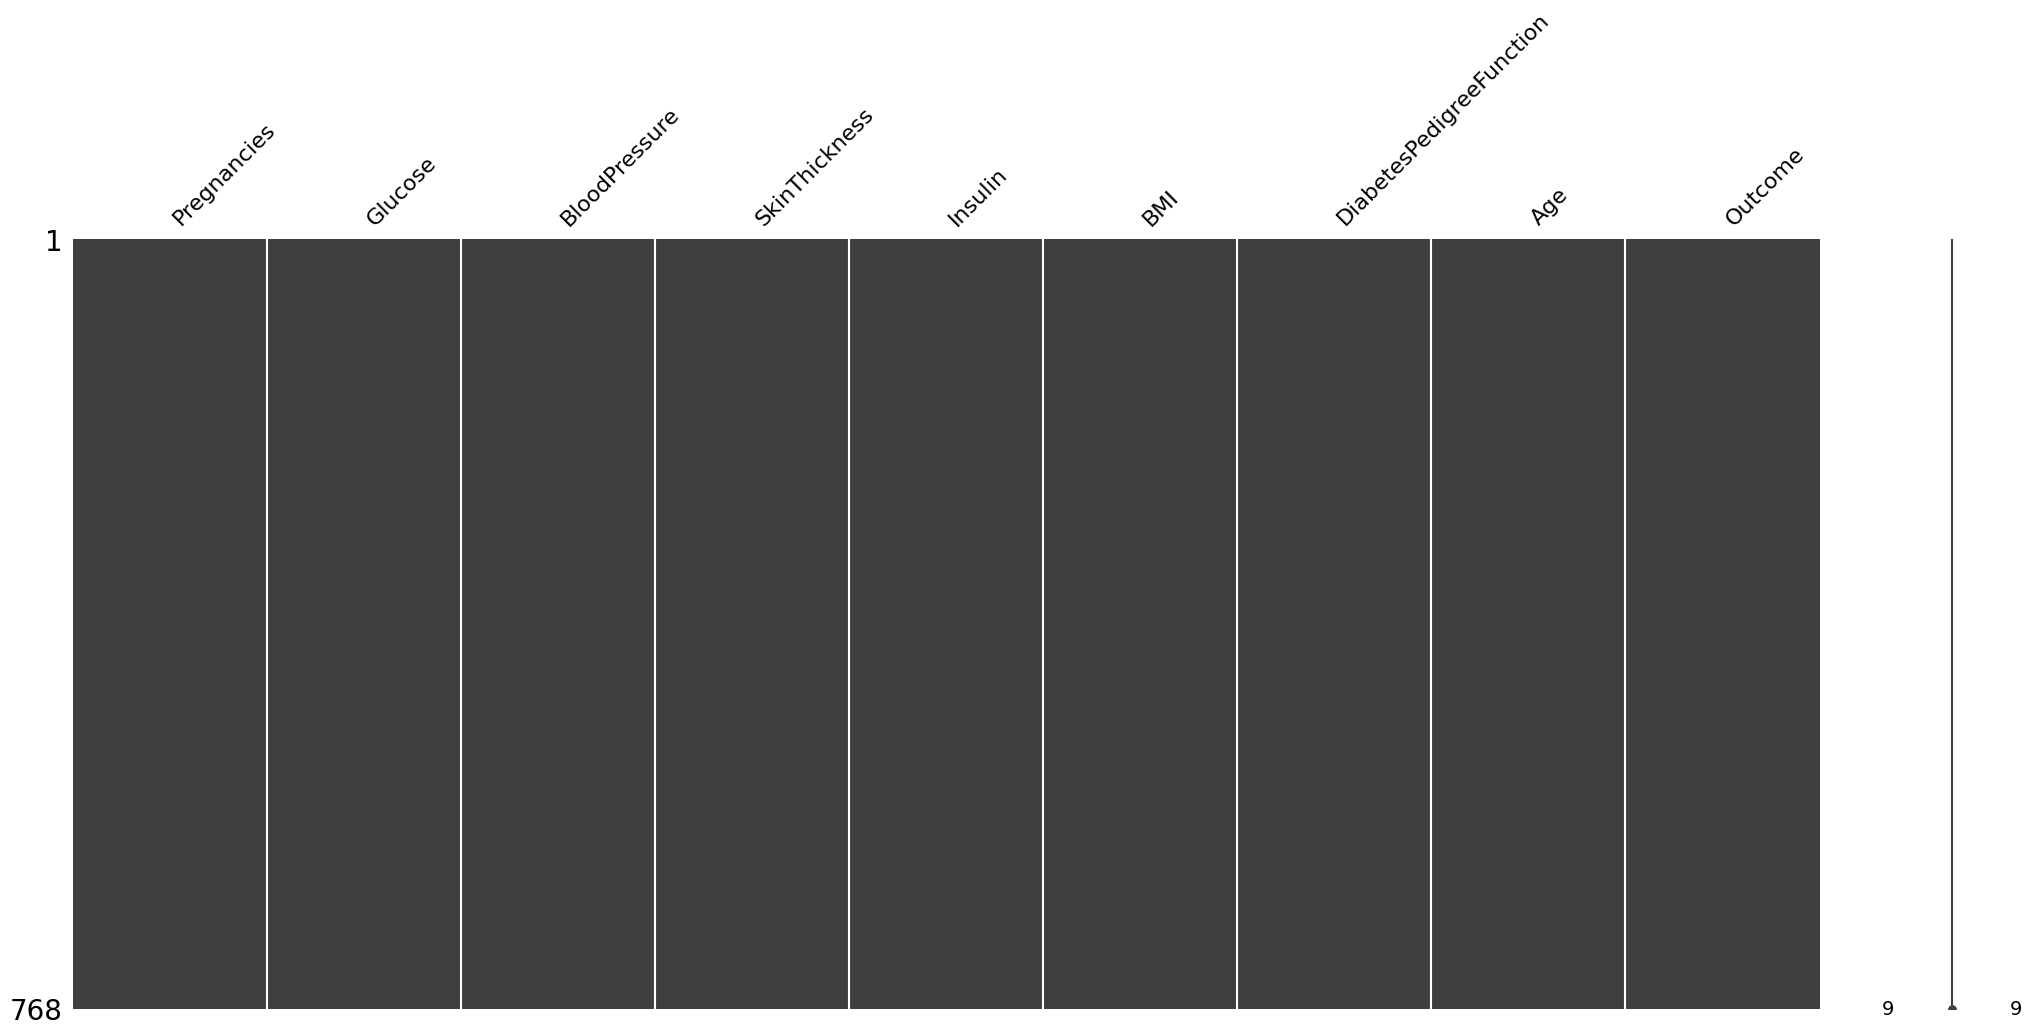

In [11]:
#visualiser les valeurs manquantes avec missingno
msno.matrix(df)
plt.show()

In [12]:
df.stb.missing().sum()

missing       0.0
total      6912.0
percent       0.0
dtype: float64

## On constate que le jeu de donnees ne contient aucune valeurs manquantes.

In [13]:
## Colonnes contenant des valeurs nulles impossibles
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

## Remplacer les 0 par la médiane de chaque colonne
# La médiane est utilisée car elle est robuste aux valeurs aberrantes
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [14]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,30.5,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,23,30.5,30.1,0.349,47,1


In [15]:
# voir les doublons
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [16]:
# Compter le nombre de lignes dupliquées
df.duplicated().sum()

np.int64(0)

## On constate que le jeu de données ne contient pas de doublons.

<Axes: ylabel='Pregnancies'>

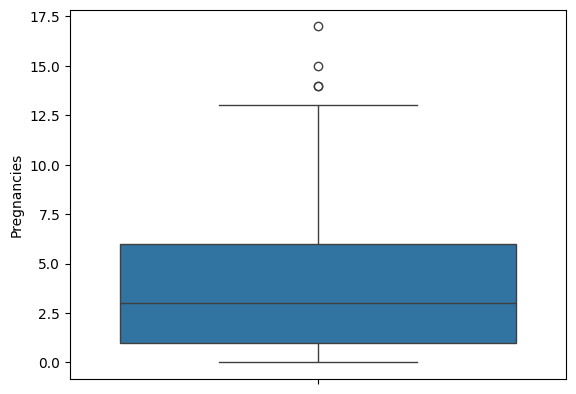

In [17]:
sns.boxplot(df['Pregnancies'])

- On constate que la variable Pregnancies contient de valeurs aberrantes mais aussi la distribution n'est pas asymetrique.

<Axes: ylabel='Glucose'>

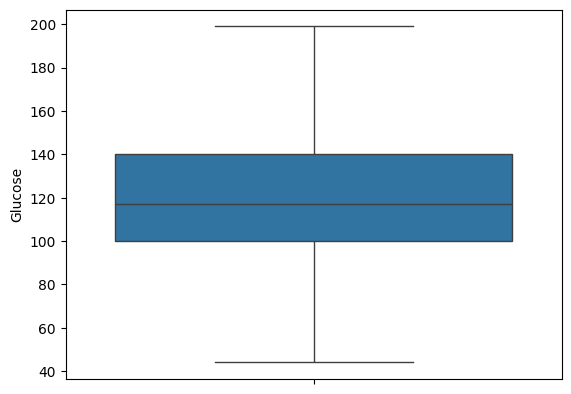

In [18]:
sns.boxplot(df['Glucose'])

- On constate que la variable Glucose contient de valeurs aberrantes mais aussi la distribution n'est pas asymetrique.

<Axes: ylabel='BloodPressure'>

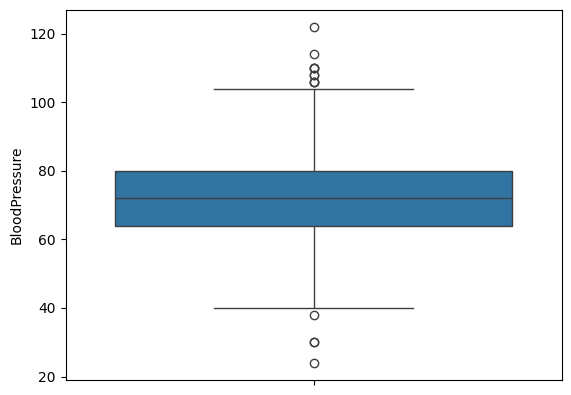

In [19]:
sns.boxplot(df['BloodPressure'])

- On constate que la variable BloodPressure contient de valeurs aberrantes mais aussi la distribution est asymetrique.

<Axes: ylabel='Insulin'>

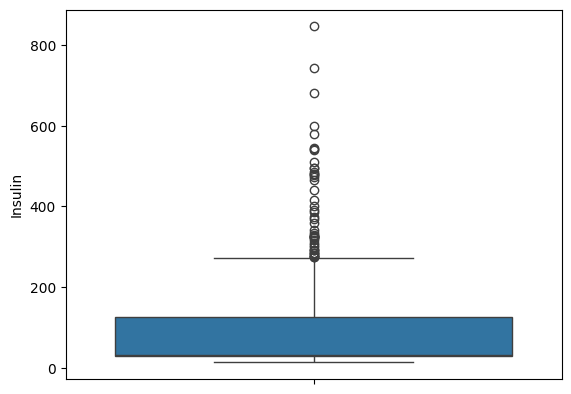

In [20]:
sns.boxplot(df['Insulin'])

- On constate que la variable Pregnancies contient de valeurs aberrantes mais aussi la distribution n'est pas asymetrique.

<Axes: ylabel='SkinThickness'>

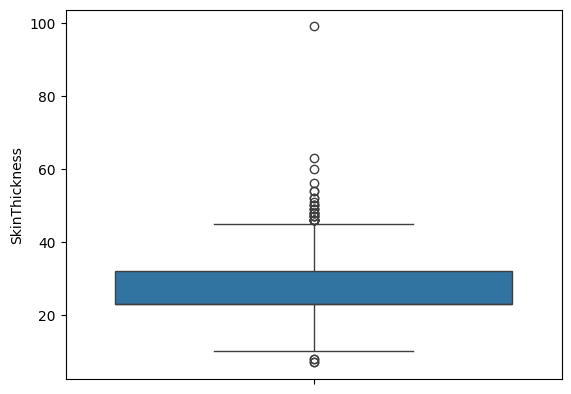

In [21]:
sns.boxplot(df['SkinThickness'])

<Axes: ylabel='DiabetesPedigreeFunction'>

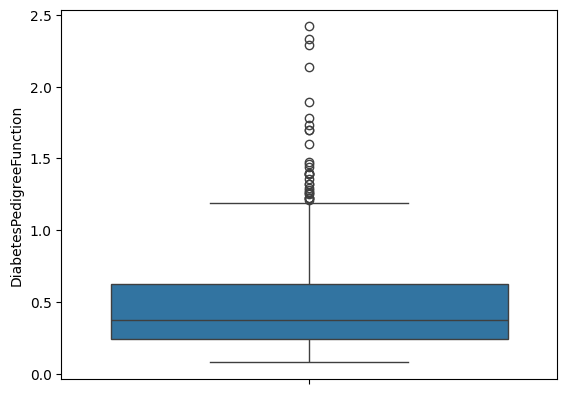

In [22]:
sns.boxplot(df['DiabetesPedigreeFunction'])

<Axes: ylabel='Age'>

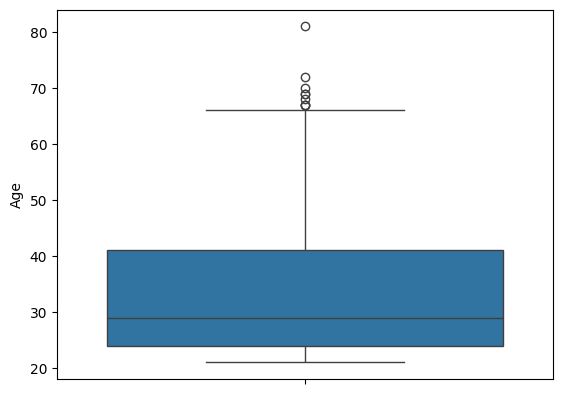

In [23]:
sns.boxplot(df['Age'])

## Les données ont été analysées afin de détecter les valeurs manquantes, aberrantes et les doublons.

- Aucune valeur manquante explicite n’a été trouvée.

- Cependant, certaines variables contenaient des valeurs nulles impossibles (ex : Glucose = 0). Ces valeurs ont été remplacées par la médiane.

- Aucun doublon significatif n’a été détecté.

- Des valeurs aberrantes ont été identifiées mais conservées, car elles peuvent correspondre à des cas médicaux réels importants.

In [24]:
# Calcul des quartiles pour toutes les variables
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calcul de l'IQR (intervalle interquartile)
IQR = Q3 - Q1

# Détection des valeurs aberrantes
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

# Nombre d'outliers par variable
outliers.sum()

Pregnancies                  4
Glucose                      0
BloodPressure               14
SkinThickness               35
Insulin                     49
BMI                          8
DiabetesPedigreeFunction    29
Age                          9
Outcome                      0
dtype: int64

* L’analyse des valeurs aberrantes a montré la présence d’observations extrêmes dans plusieurs variables, notamment Insulin, SkinThickness et DiabetesPedigreeFunction. Ces valeurs reflètent la variabilité biologique entre les patients et correspondent à des cas médicaux plausibles.

- L’absence d’outliers dans la variable Glucose indique une distribution stable pour cette variable clé.

- Dans le contexte de la détection du diabète, ces valeurs aberrantes ont été conservées, car elles représentent potentiellement des patients à haut risque et contribuent à améliorer la performance des modèles de prédiction.

## 4. Séparer les donnes en deux parties la variable en entrée et la variable de sortie 

- X → toutes les variables explicatives (features)

- y → la variable cible (Outcome)

In [25]:
# Séparer les variables explicatives (features) de la variable cible
X = df.drop("Outcome", axis=1)  # Toutes les colonnes sauf Outcome
y = df["Outcome"]               # La colonne cible Outcome

# Vérifier les dimensions
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (768, 8)
Dimensions de y : (768,)


## Dans cette étape, nous avons séparé les variables explicatives (X) de la variable cible (y). Les variables explicatives contiennent toutes les caractéristiques du patient permettant de prédire le diabète, tandis que la variable cible indique si le patient est diabétique ou non. Cette séparation est nécessaire pour entraîner correctement les modèles de machine learning et éviter tout mélange entre features et target.

## 5. Divisez le jeu de données en deux partie (données d'entraînement et données de test) on considère 20% pour les données de test et 80% pour des données d’entrainements. 

## Objectif

- 80 % des données → entraînement (X_train, y_train)

- 20 % des données → test (X_test, y_test)

  
Permet d’évaluer la performance des modèles sur des données inconnues.

In [26]:
from sklearn.model_selection import train_test_split

# Diviser les données en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,               # features et target
    test_size=0.2,      # 20% pour test, 80% pour train
    random_state=42     # pour reproduire les mêmes résultats
)

In [27]:
# Vérifier les dimensions
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (614, 8)
X_test  : (154, 8)
y_train : (614,)
y_test  : (154,)


## 1. X_train : (614, 8)

- Contient 614 observations pour entraîner les modèles

- Chaque observation a 8 caractéristiques : Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age

## 2.X_test : (154, 8)

- Contient 154 observations utilisées uniquement pour tester les modèles

- Permet de mesurer la performance sur des données jamais vues par le modèle

## 3. y_train : (614,)

- Les étiquettes correspondantes à X_train

- Outcome = 0 (non diabétique) ou 1 (diabétique)

## 4. y_test : (154,)

- Les étiquettes correspondant à X_test

- Sert pour comparer les prédictions du modèle avec la réalité

- La division permet d’entraîner les modèles sur 614 patients et de tester leur performance sur 154 patients. Ceci garantit que l’évaluation des modèles est réaliste et non biaisée.

## 6. Créez et entrainer les modèles lister en question 2. 

## Objectif

- Créer plusieurs modèles de machine learning

- Les entraîner sur X_train et y_train

- Évaluer leur précision sur le jeu de test (X_test, y_test)

In [28]:
## Creation du model
model_logist =  LogisticRegression()
## entrainer le modele
model_logist.fit(X_train,y_train)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
## Creation du model
model_deci_tree =  DecisionTreeClassifier()
## entrainer le modele
model_deci_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
## Creation du model
model_knn =  KNeighborsClassifier()
## entrainer le modele
model_knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
## Creation du model
model_random_forest = RandomForestClassifier()
## entrainer le modele
model_random_forest.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
## Creation du model
model_svm =  SVC()
## entrainer le modele
model_svm.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
scaler = StandardScaler()                # Crée un objet StandardScaler
X_train_scaled = scaler.fit_transform(X_train)  # Standardisation sur les données d'entraînement
X_test_scaled = scaler.transform(X_test)        # Même transformation sur les données de test

In [34]:
# Création des modèles
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
}

In [35]:
# Creation du Dictionnaire pour stocker les scores
model_scores = {}

for name, model in models.items():
    # Pour SVM et KNN, on utilise les données standardisées
    if name in ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Pour Decision Tree, Random Forest, on peut utiliser X brut
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calcul de l'accuracy
    acc = accuracy_score(y_test, y_pred)
    model_scores[name] = acc

In [36]:
 # Affichage des résultats
print(f"--- {name} ---")
print(f"Accuracy : {acc:.2f}")
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("\n")

--- Support Vector Machine ---
Accuracy : 0.75
Confusion Matrix :
 [[84 15]
 [23 32]]
Classification Report :
               precision    recall  f1-score   support

           0       0.79      0.85      0.82        99
           1       0.68      0.58      0.63        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154





## Methode de matrice de confusion par graphique

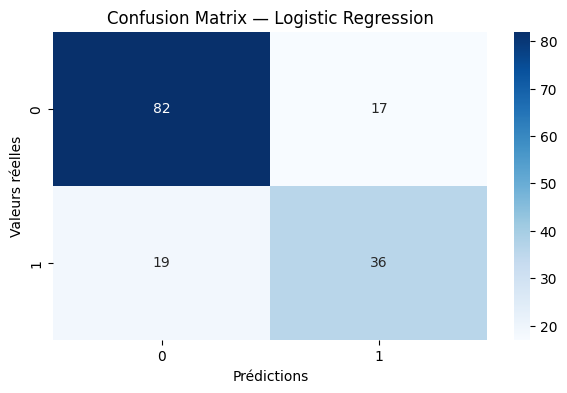

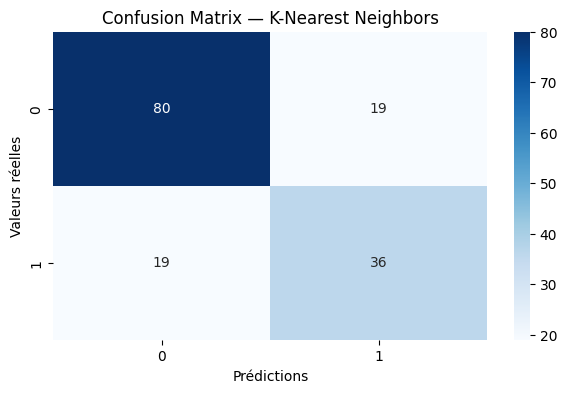

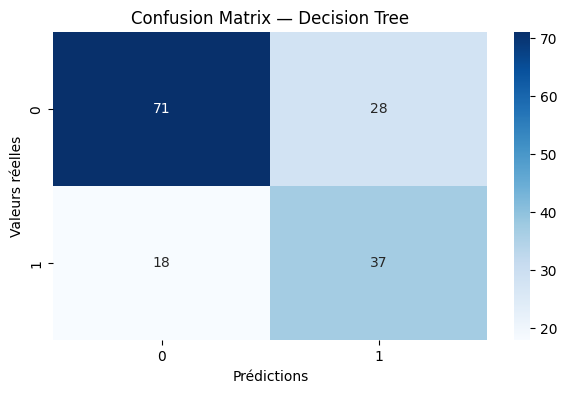

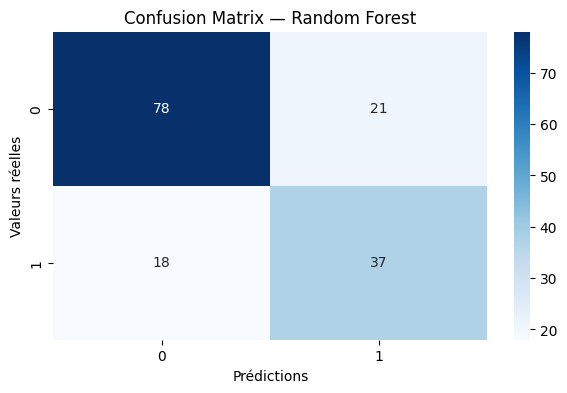

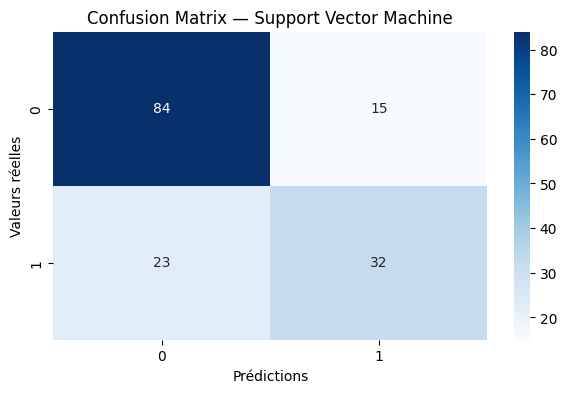

In [37]:
for name, model in models.items():
    if name in ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Prédictions")
    plt.ylabel("Valeurs réelles")
    
    plt.show()

In [38]:
def metrics(actuals, predictions):
    print("Accuracy: {:.5f}".format(accuracy_score(actuals, predictions)))
    print("Precision: {:.5f}".format(precision_score(actuals, predictions)))
    print("Recall: {:.5f}".format(recall_score(actuals, predictions)))
    print("F1-score: {:.5f}".format(f1_score(actuals, predictions)))

In [39]:
print("Evaluation of Decision Tree Model")
print()
metrics(y_test, y_pred.round())

Evaluation of Decision Tree Model

Accuracy: 0.75325
Precision: 0.68085
Recall: 0.58182
F1-score: 0.62745


## 7. Évaluer chaque modèle entrainer en fonction des métriques. 

In [40]:
for name, model in models.items():
    
    # Prédictions
    if name in ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    print("=================================")
    print(f"Modèle : {name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))

Modèle : Logistic Regression
Accuracy : 0.7662337662337663
Modèle : K-Nearest Neighbors
Accuracy : 0.7532467532467533
Modèle : Decision Tree
Accuracy : 0.7012987012987013
Modèle : Random Forest
Accuracy : 0.7467532467532467
Modèle : Support Vector Machine
Accuracy : 0.7532467532467533


In [41]:
   # Rapport détaillé
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82        99
           1       0.68      0.58      0.63        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



## Évaluation des modèles

- Les résultats montrent que le modèle de régression logistique offre la meilleure performance avec une accuracy d’environ 76,6 %, suivi de près par la forêt aléatoire. Les modèles KNN et SVM présentent des performances similaires, tandis que l’arbre de décision est légèrement moins performant. Globalement, tous les modèles testés obtiennent des résultats proches, ce qui indique que les variables explicatives permettent une prédiction correcte mais perfectible. La régression logistique apparaît donc comme le modèle le plus adapté dans ce cas.

- Le meilleur modèle est Logistic Regression car il a la plus haute accuracy.

## 8. Faite une étude de comparaisons des différents modèles implémentés sur la base des métriques. 

- L’analyse du rapport de classification montre que le modèle obtient une accuracy de 75 %, ce qui indique une performance globale satisfaisante. Cependant, une analyse plus approfondie révèle que le modèle est plus performant pour la classe des patients non diabétiques que pour celle des patients diabétiques.

- En effet, le recall pour la classe diabétique est de 0.58, ce qui signifie que près de 42 % des patients diabétiques ne sont pas détectés par le modèle. Cette situation est problématique dans un contexte médical, car l’objectif principal est de détecter un maximum de patients malades.

- Par conséquent, bien que le modèle présente de bonnes performances globales, il nécessite des améliorations afin d’augmenter la sensibilité (recall) pour la détection des patients diabétiques.

- Dans un problème médical, on privilégie le recall de la classe malade (1)
- On préfère détecter trop de malades que d’en rater.

## 9. Sauvegarder le meilleur modèle.

In [42]:
!pip install joblib

Defaulting to user installation because normal site-packages is not writeable


In [43]:
import joblib

# Récupérer le modèle de régression logistique
logistic_model = models["Logistic Regression"]

In [47]:
# Sauvegarder avec l'ordre des features
logistic_model.feature_names = list(X.columns)

# Sauvegarder aussi le scaler (important pour SVM et KNN mais pas obligatoire pour Logistic)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


# Sauvegarder les deux
joblib.dump(logistic_model, "modele_diabete_logistic.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [48]:
print("Le Modèle Logistic Regression sauvegardé!")
print(f"   Features: {list(X.columns)}")
print(f"   Accuracy: {model_scores['Logistic Regression']:.2f}")

✅ Modèle Logistic Regression sauvegardé!
   Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
   Accuracy: 0.77


## Le meilleur modèle sélectionné a été sauvegardé à l’aide de la bibliothèque joblib afin de permettre sa réutilisation ultérieure sans nécessiter un nouvel entraînement.